In [1]:
# --- preparação do ambiente (rode esta célula primeiro) ---
# Acha a raiz do projeto; se não existir, estamos no Colab e o repositório é clonado.
import os
import pathlib
import subprocess

REPOSITORIO = "https://github.com/thxggz/dr1-at-algoritmos.git"
DESTINO_CLONE = pathlib.Path("/content/dr1-at-algoritmos")


def raiz_do_projeto() -> pathlib.Path | None:
    """Primeiro diretório, subindo a partir do atual, que contenha src/counters.py."""
    for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (base / "src" / "counters.py").exists():
            return base
    return None


raiz = raiz_do_projeto()
if raiz is None:
    if not DESTINO_CLONE.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPOSITORIO, str(DESTINO_CLONE)],
            check=True,
        )
    raiz = DESTINO_CLONE
os.chdir(raiz)
print(f"raiz do projeto: {raiz}")
print("o código vive em src/; este notebook importa e demonstra")

raiz do projeto: C:\Users\kikea\dr1-at-aed
o código vive em src/; este notebook importa e demonstra


# Exercício 5 — Pilha, fila e árvore de expressão

**Henrique Goldstein Maluhy Mendes Amaral** · Infnet · DR1_AT — Algoritmos e Estruturas de Dados

Este notebook cobre **um** exercício. O código está em `src/`, testado por `pytest`; aqui ele é importado e demonstrado. A primeira célula prepara o ambiente — rode-a antes das outras, ou use **Ambiente de execução → Executar tudo**.

**Os doze exercícios:**

1. [Exercício 1](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex01_buscas.ipynb)
2. [Exercício 2](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex02_ordenacoes_quadraticas.ipynb)
3. [Exercício 3](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex03_otimizacao.ipynb)
4. [Exercício 4](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex04_hashtable.ipynb)
5. Exercício 5 **→ você está aqui**
6. [Exercício 6](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex06_simulador_de_filas.ipynb)
7. [Exercício 7](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex07_recursao_diretorios.ipynb)
8. [Exercício 8](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex08_programacao_dinamica.ipynb)
9. [Exercício 9](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex09_quicksort_quickselect.ipynb)
10. [Exercício 10](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex10_lista_encadeada.ipynb)
11. [Exercício 11](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex11_lista_dupla_deque.ipynb)
12. [Exercício 12](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex12_motor_de_indexacao.ipynb)

---


---
# Seção 0 — Instrumentação compartilhada

Antes dos exercícios, a peça de que todos dependem.

Existe **um único** contador, definido em `src/counters.py` e reutilizado pelos
12 exercícios. Sem isso, "o insertion sort faz 4.193 comparações" e "a BST faz
1.904.423" não seriam números comparáveis.

```python
@dataclass
class Counters:
    comparisons: int = 0   # comparações de chaves
    copies: int = 0        # movimentações (1 troca = 3 cópias)
    calls: int = 0         # chamadas recursivas
    hops: int = 0          # saltos de ponteiro em estrutura encadeada
```

**Os três primeiros são exigência do enunciado.** O quarto, `hops`, foi
acrescentado — e a razão é o exercício 10: com ponteiro `tail`, `insert_last`
faz 0 comparações e 1 cópia, *exatamente como* a versão sem `tail`. Os
contadores obrigatórios são cegos para a diferença entre O(1) e O(n) ali. Sem
`hops`, a evidência quantitativa que a rubrica cobra não existiria.

**Critérios fixos, válidos no trabalho inteiro:**

- uma **troca** conta 3 cópias (`tmp = a; a = b; b = tmp`); um **deslocamento**
  conta 1;
- uma **sondagem** de busca (linear, binária ou descida em BST) conta **uma**
  comparação de três vias, não duas;
- toda função instrumentada aceita um `Counters` do chamador e tem um irmão
  `*_counted` que devolve `(resultado, Counters)`.

In [2]:
from __future__ import annotations

import math
import pathlib
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebook" else pathlib.Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
FIGURAS = RAIZ / "figures"
FIGURAS.mkdir(exist_ok=True)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.figsize": (9, 4.5), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})
warnings.filterwarnings("ignore", category=FutureWarning)

from src.counters import COPIES_PER_SWAP, RANDOM_SEED, Counters

print(f"semente dos experimentos: {RANDOM_SEED}")
print(f"uma troca conta {COPIES_PER_SWAP} cópias")
print(f"campos do contador: {list(Counters().as_dict())}")

semente dos experimentos: 42
uma troca conta 3 cópias
campos do contador: ['comparisons', 'copies', 'calls', 'hops']


In [3]:
def mostrar(df: pd.DataFrame, colunas: list[str] | None = None, titulo: str = "") -> pd.DataFrame:
    """Exibe a tabela de medições, opcionalmente só com as colunas pedidas."""
    if titulo:
        print(titulo)
    return df[colunas] if colunas else df


def grafico_loglog(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Gráfico log-log — usado sempre que há 4 ou mais pontos por curva."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def grafico_razao(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Razão contra a curva teórica: reta horizontal = a classe está certa."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def veredito(texto: str) -> None:
    """Conclusão calculada a partir da tabela imediatamente acima."""
    print("\n" + "=" * 78)
    print(texto)
    print("=" * 78)

---
# Exercício 5 — Pilha, fila e árvore de expressão

## Enunciado
Implementar `Stack` e `Queue` sobre array de **capacidade fixa**, com exceções
próprias para overflow e underflow e fila com wraparound; montar uma árvore
binária de expressão a partir de notação pós-fixa usando a `Stack`, detectando
entradas inválidas; e avaliar de duas formas — pós-ordem recursiva e iterativa.

## Implementação — `src/stack_queue.py`

**Decisão de projeto 1 — capacidade fixa de verdade.** O array é alocado uma vez
e nunca cresce. Com array que cresce sozinho, "overflow" nunca acontece e não há
o que testar.

**Decisão de projeto 2 — a fila guarda `_head` e `_size`, não `_head` e `_tail`.**
Com dois índices, `head == tail` é ambíguo: significa vazia **e** cheia. As
saídas clássicas são sacrificar uma posição ou guardar um bit; guardar `_size`
resolve sem desperdiçar posição e deixa `__len__` em O(1).

In [4]:
from src.stack_queue import (OPERATORS, DivisionByZeroError, InsufficientOperandsError,
                             LeftoverOperandsError, Queue, QueueOverflowError,
                             QueueUnderflowError, Stack, StackOverflowError,
                             StackUnderflowError, UnknownTokenError, bench_queue_wraparound,
                             bench_recursion_depth, bench_stack_queue_operations,
                             build_expression_tree, chained_postfix, evaluate_iterative,
                             evaluate_recursive, to_infix, tree_height, tree_size)

pilha = Stack(3, [1, 2, 3])
assert pilha.is_full() and pilha.peek() == 3
try:
    pilha.push(4)
except StackOverflowError as erro:
    print(f"StackOverflowError: {erro}")
fila = Queue(3)
try:
    fila.dequeue()
except QueueUnderflowError as erro:
    print(f"QueueUnderflowError: {erro}")

# árvore de expressão
raiz = build_expression_tree("5 1 2 + 4 * + 3 -")
assert to_infix(raiz) == "((5 + ((1 + 2) * 4)) - 3)"
recursiva = evaluate_recursive(raiz)
iterativa = evaluate_iterative(raiz)
assert recursiva.value == iterativa.value == 14
print(f'\n"5 1 2 + 4 * + 3 -"  →  {to_infix(raiz)}  =  {recursiva.value}')
print(f"  nós: {tree_size(raiz)} · altura: {tree_height(raiz)}")
print(f"  recursiva: {recursiva.counters.calls} chamadas, profundidade {recursiva.max_depth}")
print(f"  iterativa: {iterativa.counters.calls} visitas,  profundidade {iterativa.max_depth}, "
      f"pico da pilha de operandos {iterativa.peak_operand_stack}")

StackOverflowError: push em pilha cheia: capacidade 3 esgotada (topo atual: 3)
QueueUnderflowError: dequeue em fila vazia (capacidade 3)

"5 1 2 + 4 * + 3 -"  →  ((5 + ((1 + 2) * 4)) - 3)  =  14
  nós: 9 · altura: 5
  recursiva: 9 chamadas, profundidade 5
  iterativa: 9 visitas,  profundidade 5, pico da pilha de operandos 3


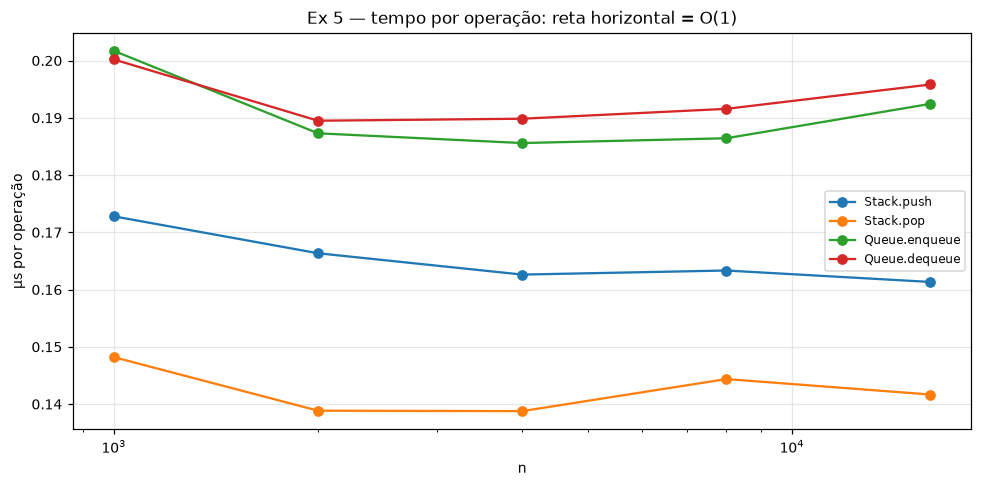

CUSTO POR OPERAÇÃO (µs) — todas com hops = 0
n               1000   2000   4000   8000  16000  pior/melhor
algoritmo                                                    
Queue.dequeue 0.2002 0.1895 0.1898 0.1916 0.1958       1.0565
Queue.enqueue 0.2017 0.1873 0.1856 0.1864 0.1925       1.0867
Stack.pop     0.1482 0.1388 0.1388 0.1444 0.1417       1.0679
Stack.push    0.1728 0.1663 0.1626 0.1633 0.1613       1.0710

n cresceu 16× e o custo por operação variou no máximo 1.09× — ruído de máquina, não tendência.
Todas as operações: 0 saltos de ponteiro. Θ(1) de pior caso, não amortizado.


In [5]:
operacoes = pd.DataFrame(bench_stack_queue_operations())
grafico_razao(operacoes, "n", "tempo_us_por_op", "algoritmo",
              "Ex 5 — tempo por operação: reta horizontal = O(1)",
              "ex05_stack_queue.png", "µs por operação")
pivo_ops = operacoes.pivot(index="algoritmo", columns="n", values="tempo_us_por_op")
pivo_ops["pior/melhor"] = pivo_ops.max(axis=1) / pivo_ops.min(axis=1)
print("CUSTO POR OPERAÇÃO (µs) — todas com hops = 0")
print(pivo_ops.to_string())
assert (operacoes["hops"] == 0).all()
veredito(
    f"n cresceu 16× e o custo por operação variou no máximo "
    f"{pivo_ops['pior/melhor'].max():.2f}× — ruído de máquina, não tendência.\n"
    "Todas as operações: 0 saltos de ponteiro. Θ(1) de pior caso, não amortizado."
)

### Caso de borda — a fila circular

In [6]:
volta = bench_queue_wraparound()
for chave in ("n", "capacidade", "posicoes_alocadas", "voltas_no_array",
              "ocupacao_maxima", "fifo_preservado", "restantes_na_fila", "copies"):
    print(f"  {chave:<22} {volta[chave]}")
veredito(
    f"{volta['n']:,} operações de enfileiramento num array de "
    f"{volta['posicoes_alocadas']} posições.\n"
    f"A cauda deu {volta['voltas_no_array']:,} voltas no array e a ordem FIFO foi preservada: "
    f"{volta['fifo_preservado']}.\n"
    "Sem wraparound, o array se esgotaria no 8º cliente."
)

  n                      10000
  capacidade             8
  posicoes_alocadas      8
  voltas_no_array        8743
  ocupacao_maxima        8
  fifo_preservado        True
  restantes_na_fila      7
  copies                 19993

10,000 operações de enfileiramento num array de 8 posições.
A cauda deu 8,743 voltas no array e a ordem FIFO foi preservada: True.
Sem wraparound, o array se esgotaria no 8º cliente.


### Recursiva × iterativa — mesmo trabalho, memória em lugares diferentes

In [7]:
profundidade = pd.DataFrame(bench_recursion_depth())
mostrar(profundidade, ["padrao", "operadores", "n", "altura", "calls_recursiva",
                       "calls_iterativa", "profundidade_recursiva", "profundidade_iterativa",
                       "pico_operandos", "recursiva_quebrou", "limite_de_recursao"],
        "AVALIAÇÃO RECURSIVA × ITERATIVA")

AVALIAÇÃO RECURSIVA × ITERATIVA


,padrao,operadores,n,altura,calls_recursiva,calls_iterativa,profundidade_recursiva,profundidade_iterativa,pico_operandos,recursiva_quebrou,limite_de_recursao
0,expressão encadeada à esquerda,50,101,51,101.0000,101,51.0000,51,2,False,1000
1,expressão encadeada à esquerda,200,401,201,401.0000,401,201.0000,201,2,False,1000
2,expressão encadeada à esquerda,800,1601,801,"1,601.0000",1601,801.0000,801,2,False,1000
3,expressão encadeada à esquerda,3200,6401,3201,NaN,6401,NaN,3201,2,True,1000
4,expressão encadeada à esquerda,12800,25601,12801,NaN,25601,NaN,12801,2,True,1000
5,expressão encadeada à direita,50,101,51,101.0000,101,51.0000,51,51,False,1000
6,expressão encadeada à direita,200,401,201,401.0000,401,201.0000,201,201,False,1000
7,expressão encadeada à direita,800,1601,801,"1,601.0000",1601,801.0000,801,801,False,1000
8,expressão encadeada à direita,3200,6401,3201,NaN,6401,NaN,3201,3201,True,1000
9,expressão encadeada à direita,12800,25601,12801,NaN,25601,NaN,12801,12801,True,1000


In [8]:
quebrou = profundidade[profundidade["recursiva_quebrou"]]
inteiro = profundidade[~profundidade["recursiva_quebrou"]]
maior = quebrou.iloc[-1]
veredito(
    "MESMO TRABALHO: calls_recursiva == calls_iterativa == número de nós, em todas as linhas\n"
    "MESMA PROFUNDIDADE: as duas atingem a altura da árvore\n"
    f"DIFERENÇA: a recursiva levantou RecursionError a partir de altura "
    f"{int(quebrou['altura'].min()):,} (limite do Python: {int(maior['limite_de_recursao']):,})\n"
    f"           a iterativa chegou a altura {int(maior['altura']):,} sem problema\n\n"
    "O teto é do INTERPRETADOR, não do algoritmo. A pilha explícita mora no heap.\n\n"
    "E o formato da árvore separa duas memórias que costumam ser confundidas:\n"
    "  árvore à esquerda → pilha de operandos fica em 2\n"
    "  árvore à direita  → pilha de operandos chega à altura inteira"
)


MESMO TRABALHO: calls_recursiva == calls_iterativa == número de nós, em todas as linhas
MESMA PROFUNDIDADE: as duas atingem a altura da árvore
DIFERENÇA: a recursiva levantou RecursionError a partir de altura 3,201 (limite do Python: 1,000)
           a iterativa chegou a altura 12,801 sem problema

O teto é do INTERPRETADOR, não do algoritmo. A pilha explícita mora no heap.

E o formato da árvore separa duas memórias que costumam ser confundidas:
  árvore à esquerda → pilha de operandos fica em 2
  árvore à direita  → pilha de operandos chega à altura inteira


### Casos de borda — entradas inválidas na montagem da árvore

In [9]:
casos = [
    ("", "expressão vazia"),
    ("3 +", "operador sem operandos suficientes"),
    ("1 2 3", "sobra de operandos no fim"),
    ("3 4 %", "token desconhecido"),
    ("5 0 /", "divisão por zero (só na avaliação)"),
]
for expressao, descricao in casos:
    try:
        arvore = build_expression_tree(expressao)
        evaluate_recursive(arvore)
    except Exception as erro:
        print(f"  {expressao!r:<12} {descricao:<38} → {type(erro).__name__}")
        print(f"               {str(erro)[:95]}")

# capacidade fixa de verdade: com pilha pequena, montar estoura
try:
    build_expression_tree("1 2 3 + +", capacity=2)
except StackOverflowError as erro:
    print(f"\n  capacidade 2 numa expressão que precisa de 3 → StackOverflowError")
    print(f"               {erro}")

  ''           expressão vazia                        → EmptyExpressionError
               expressão pós-fixa vazia: nada a montar
  '3 +'        operador sem operandos suficientes     → InsufficientOperandsError
               operador '+' na posição 2 precisa de 2 operandos, mas a pilha tem 1
  '1 2 3'      sobra de operandos no fim              → LeftoverOperandsError
               expressão terminou com 3 valores na pilha, esperado 1. Sobraram operandos sem operador: ['1', '
  '3 4 %'      token desconhecido                     → UnknownTokenError
               token '%' não é operando numérico nem operador (*, +, -, /, ^)
  '5 0 /'      divisão por zero (só na avaliação)     → DivisionByZeroError
               divisão por zero ao avaliar 5 / 0

  capacidade 2 numa expressão que precisa de 3 → StackOverflowError
               push em pilha cheia: capacidade 2 esgotada (topo atual: ExpressionNode('2'))
